<div style="display:flex; align-items:center; justify-content:space-between; background:linear-gradient(135deg,#0F0F1A 0%,#1A1A2E 100%); padding:28px 36px; border-radius:14px; margin-bottom:16px;">
  <div>
    <h1 style="color:white; margin:0; font-size:2.2em; font-weight:900;">Semana 4 · Seaborn, Plotly Express y Dashboards</h1>
    <p style="color:#00C9A7; margin:8px 0 0; font-size:1.1em;">Data Science Fundamentals — SKILLNEST</p>
    <p style="color:#888; margin:4px 0 0; font-size:0.9em;">Seaborn clásico → Plotly Express → Primer Dashboard con Dash</p>
  </div>
  <img src="images/LOGO-CORREO_x.png" width="130"/>
</div>

## 📅 Agenda de hoy

| Bloque | Tema | Tiempo |
|--------|------|---------|
| **1** | Seaborn: los gráficos esenciales (histplot, boxplot, barplot, heatmap) | 50 min |
| **2** | Plotly Express: gráficos interactivos con 1 línea | 50 min |
| **3** | Dash: tu primer dashboard web | 30 min |
| **4** | Mini-taller | 30 min |

**Datasets de hoy (sin descargar nada):**
- 🐧 `penguins` — 344 pingüinos de 3 especies (incorporado en Seaborn)
- 🌍 `gapminder` — países del mundo 1952–2007 (incorporado en Plotly)
- 🍽️ `tips` — propinas en restaurante (incorporado en Seaborn)

---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

sns.set_theme(style="whitegrid", context="talk")

# Cargar datasets
penguins = sns.load_dataset("penguins").dropna()
tips     = sns.load_dataset("tips")
gapminder = px.data.gapminder()

print(f"penguins: {penguins.shape}")
print(f"tips:     {tips.shape}")
print(f"gapminder:{gapminder.shape}")
print("\n✅ Todo listo")

penguins: (333, 7)
tips:     (244, 7)
gapminder:(1704, 8)

✅ Todo listo


---
<div style="background: linear-gradient(135deg, #1A1A2E 0%, #004080 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900;">🎨 Bloque 1 — Seaborn: los gráficos esenciales</h2>
  <p style="color:rgba(255,255,255,0.85); margin:6px 0 0;">Menos código que Matplotlib, más bonito, diseñado para DataFrames</p>
</div>

## ¿Qué es Seaborn?

Seaborn está construida **encima de Matplotlib**. La diferencia:

| | Matplotlib | Seaborn |
|--|------------|----------|
| Cantidad de código | Mucho | Poco |
| Trabaja con DataFrames | Parcialmente | Nativo |
| Aspecto visual | Manual | Bonito por defecto |
| Estadísticas automáticas | ❌ | ✅ (IC 95%, KDE) |

```python
import seaborn as sns
```

La fórmula básica siempre es:
```python
sns.tipo_de_grafico(data=df, x="columna_x", y="columna_y", hue="columna_color")
```

### 1.1 `histplot` — distribución de una variable

El histplot de Seaborn puede agregar automáticamente una **curva KDE** (Kernel Density Estimate), que es una versión suavizada del histograma. Esto nos dice dónde se concentran los datos.

In [4]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


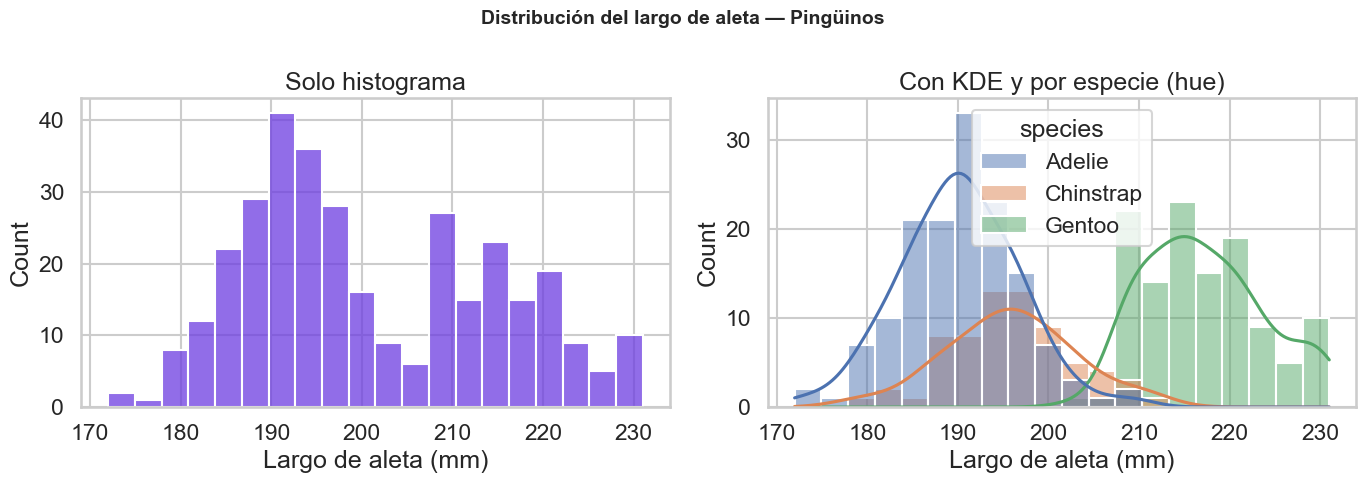

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución del largo de aleta — Pingüinos", fontsize=14, fontweight="bold")

# Izquierda: histograma simple
sns.histplot(data=penguins, x="flipper_length_mm", bins=20,
             color="#6C3CE1", ax=axes[0])
axes[0].set_title("Solo histograma")
axes[0].set_xlabel("Largo de aleta (mm)")

# Derecha: histograma + KDE + separado por especie
sns.histplot(data=penguins, x="flipper_length_mm", hue="species",
             kde=True, bins=20, alpha=0.5, ax=axes[1])
axes[1].set_title("Con KDE y por especie (hue)")
axes[1].set_xlabel("Largo de aleta (mm)")

plt.tight_layout()
plt.show()

> **¿Qué vemos?** El gráfico de la derecha muestra 3 distribuciones casi separadas — los Gentoo tienen aletas claramente más largas. Esto ya es un hallazgo útil.

### 1.2 `boxplot` — comparar distribuciones entre categorías

El boxplot de Seaborn hace en 2 líneas lo que Matplotlib hace en 15.

In [7]:
penguins.head(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male


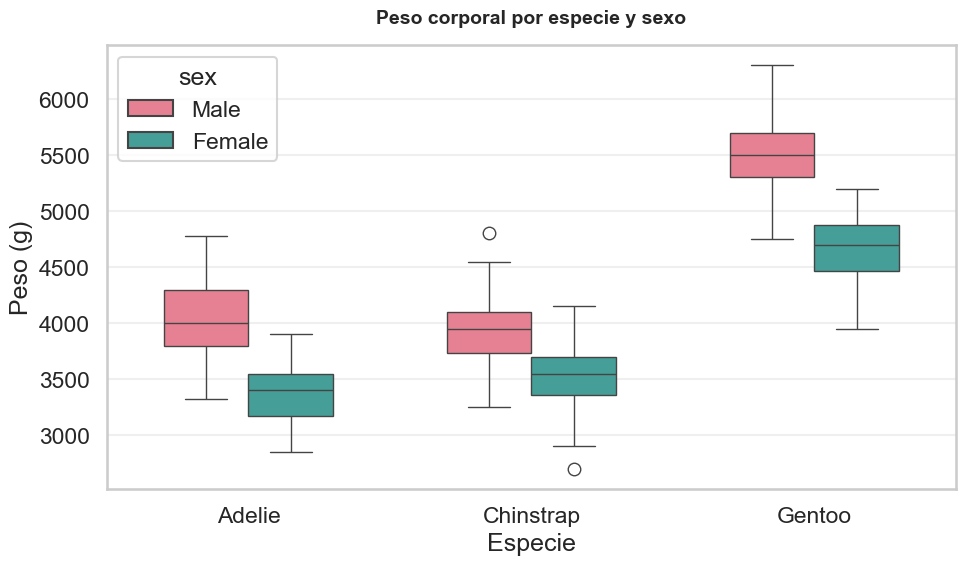

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    hue="sex",
    palette="husl",
    width=0.6,
    ax=ax
)

ax.set_title("Peso corporal por especie y sexo", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Especie")
ax.set_ylabel("Peso (g)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 `barplot` — medias con intervalo de confianza

El barplot de Seaborn calcula automáticamente el **promedio** y le agrega las **barras de error** (intervalo de confianza al 95%). Esto es estadística básica de regalo.

> Las barritas de error nos dicen: *"si repitiéramos el experimento muchas veces, el promedio real estaría dentro de este rango el 95% de las veces"*.

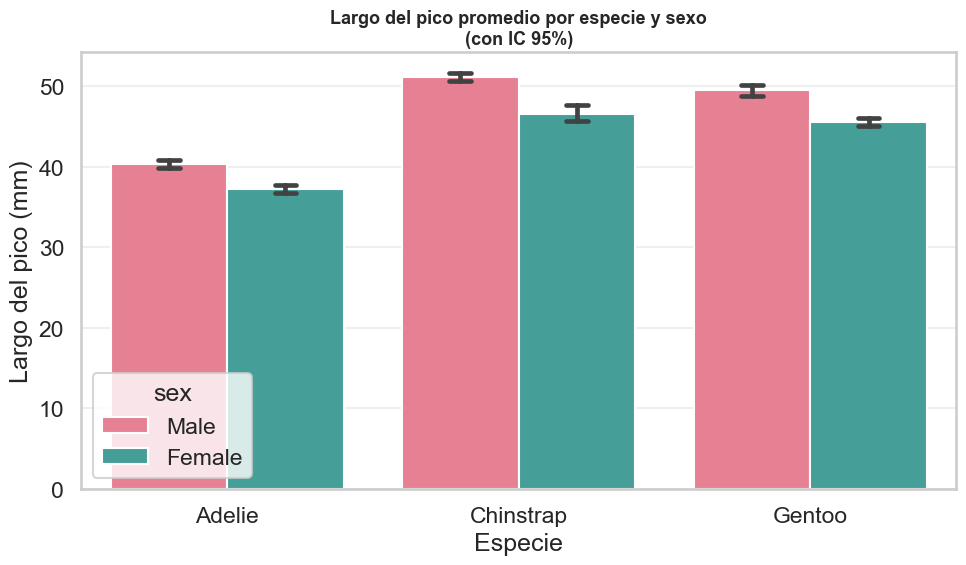

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=penguins,
    x="species",
    y="bill_length_mm",
    hue="sex",
    palette="husl",
    errorbar="ci",     # intervalo de confianza 95%
    capsize=0.15,
    ax=ax
)

ax.set_title("Largo del pico promedio por especie y sexo\n(con IC 95%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Especie")
ax.set_ylabel("Largo del pico (mm)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4 `heatmap` — matriz de correlación

El heatmap (mapa de calor) es la forma más rápida de ver **qué tan relacionadas están las variables numéricas** entre sí.

Antes de hacer el heatmap, necesitamos calcular la **matriz de correlación** con `.corr()`:

| Valor | Significado |
|-------|-------------|
| **+1.0** | Cuando una sube, la otra sube igual |
| **0.0** | No hay relación |
| **-1.0** | Cuando una sube, la otra baja |

```python
df.corr()         # calcula la matriz
sns.heatmap(...)  # la dibuja con colores
```

In [13]:
penguins[cols_num]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [12]:
# Paso 1: calcular la correlación
cols_num = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
corr = penguins[cols_num].corr()

print("Matriz de correlación:")
display(corr.round(2))

Matriz de correlación:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.23,0.65,0.59
bill_depth_mm,-0.23,1.00,-0.58,-0.47
flipper_length_mm,0.65,-0.58,1.00,0.87
body_mass_g,0.59,-0.47,0.87,1.00


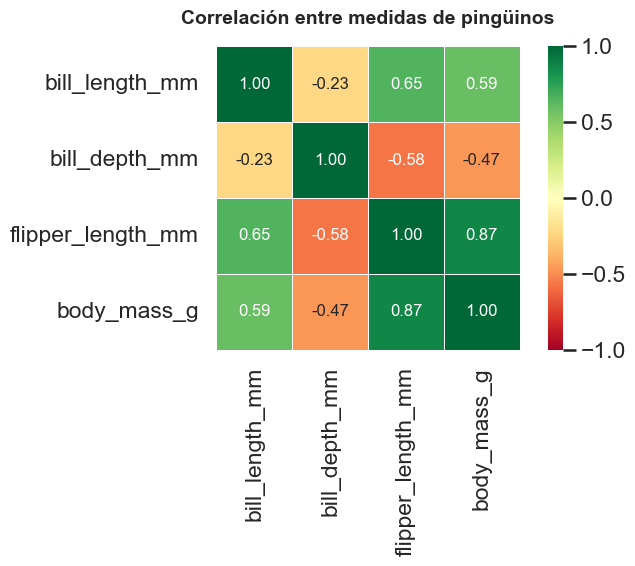

In [14]:
# Paso 2: dibujarla con heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,          # muestra el número dentro de cada celda
    fmt=".2f",           # formato del número
    cmap="RdYlGn",       # rojo=negativo, verde=positivo
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 12},
    ax=ax
)

ax.set_title("Correlación entre medidas de pingüinos", fontsize=14, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

### ¿Cómo leer el heatmap?

1. La **diagonal** siempre es 1.0 (cada variable se correlaciona perfectamente consigo misma — ignórala)
2. Busca los **verdes intensos** → variables muy relacionadas
3. Busca los **rojos intensos** → variables inversamente relacionadas
4. Los **amarillos** → poca o ninguna relación

> **Insight de este heatmap:**
> - `flipper_length_mm` y `body_mass_g` tienen correlación +0.87 — los pingüinos con aletas largas tienden a ser más pesados
> - `bill_depth_mm` y `flipper_length_mm` tienen correlación negativa — picos más profundos = aletas más cortas

### 1.5 `pairplot` — exploración visual completa (bonus)

El pairplot crea una cuadrícula de gráficos para **todas las combinaciones** de variables numéricas. Es el primer gráfico que deberías hacer cuando tienes un dataset nuevo.

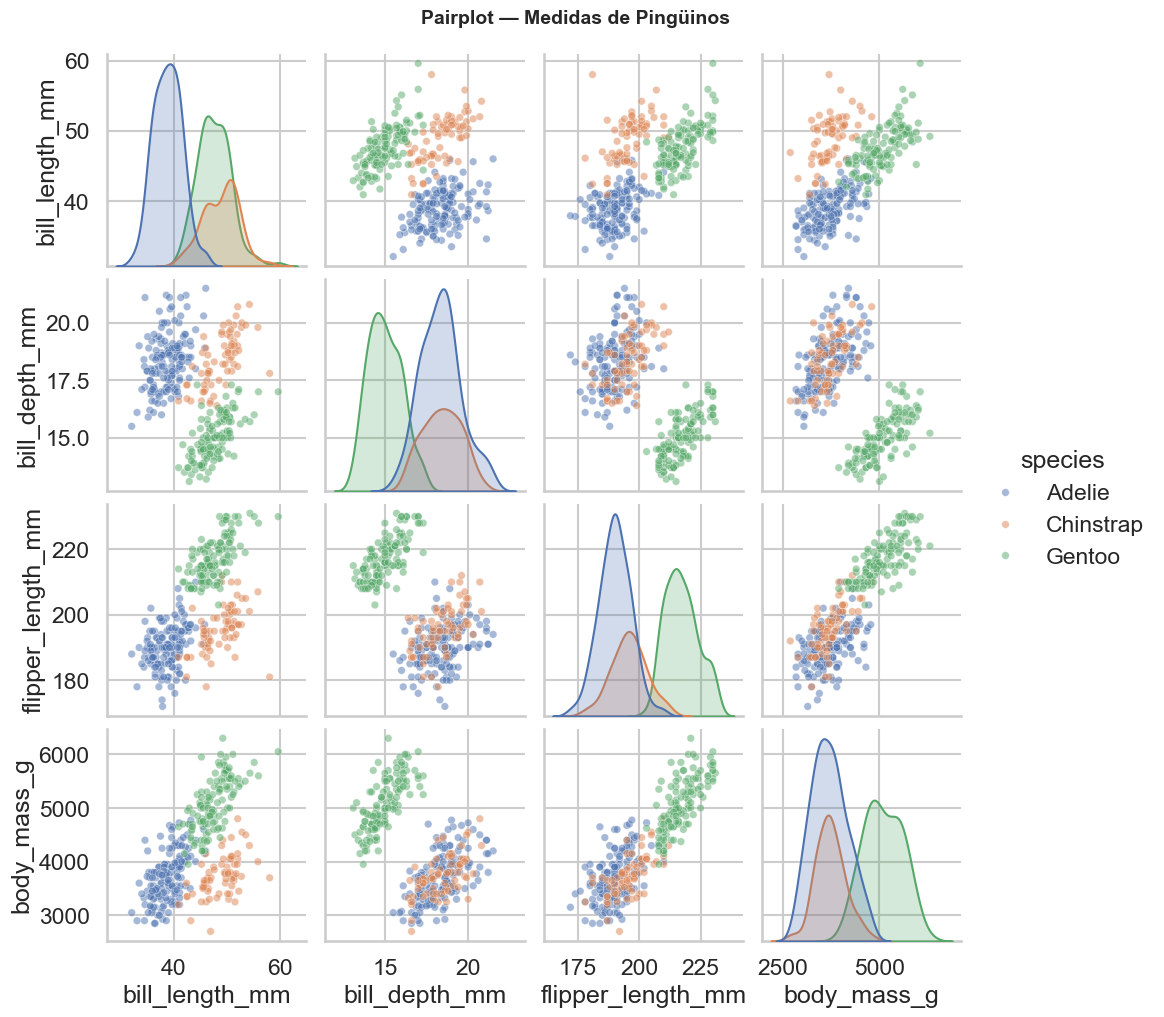

In [15]:
pair = sns.pairplot(
    penguins,
    hue="species",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 30}
)
pair.figure.suptitle("Pairplot — Medidas de Pingüinos", y=1.02, fontsize=14, fontweight="bold")
plt.show()

> **¿Por qué es útil?** De un solo vistazo puedes ver que las 3 especies están **separadas visualmente** en varios gráficos — eso significa que se pueden distinguir solo por sus medidas, sin necesidad de modelos complejos.

<div style="background:#1A1A2E; border-left:4px solid #00C9A7; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#00C9A7; font-weight:700; margin:0 0 6px;">✏️ Mini-ejercicio 1 — Seaborn</p>
  <p style="color:#CCC; margin:0;">
  Con el dataset <code>tips</code>:<br>
  (a) Crea un <code>histplot</code> de <code>total_bill</code> con KDE, separado por <code>time</code> (Lunch vs Dinner)<br>
  (b) Crea un <code>heatmap</code> de correlación de las columnas numéricas del dataset <code>tips</code><br>
  Pregunta: ¿hay correlación entre la cuenta total y la propina?
  </p>
</div>

In [ ]:
# (a) histplot de total_bill


# (b) heatmap de tips


---
<div style="background: linear-gradient(135deg, #1A1A2E 0%, #1A3A00 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <h2 style="color:#00C9A7; margin:0; font-size:1.5em; font-weight:900;">⚡ Bloque 2 — Plotly Express: gráficos interactivos</h2>
  <p style="color:rgba(255,255,255,0.85); margin:6px 0 0;">Hover, zoom y filtros incluidos. Gratis. Con 1 línea.</p>
</div>

## ¿Por qué Plotly Express?

| | Seaborn | **Plotly Express** |
|--|---------|-------------------|
| Interactividad | ❌ imagen estática | ✅ hover, zoom, filtros |
| Animaciones | ❌ | ✅ `animation_frame=` |
| Para presentar en reuniones | Regular | **Excelente** |
| Código necesario | Poco | **Mínimo** |

La fórmula siempre es:
```python
px.tipo_de_grafico(dataframe, x="col_x", y="col_y", color="col_color")
```

### ¡El gancho! 🚀
Hans Rosling fue el médico que dio la charla TED más vista sobre datos. Su secreto: **un gráfico animado de países**. Con Plotly Express lo replicamos en 1 línea.

In [16]:
gapminder

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [2]:
# El gráfico más famoso de la historia del análisis de datos — presiona ▶️
px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    animation_frame="year",
    color="continent",
    size="pop",
    hover_name="country",
    log_x=True,
    size_max=55,
    title="PIB per cápita vs Esperanza de vida (1952–2007)",
    labels={"gdpPercap": "PIB per cápita (log)", "lifeExp": "Esperanza de vida (años)"}
)

In [20]:
pip install nbformat>4.2.0  


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### `px.bar` — Barras interactivas

In [4]:
resumen

,continent,lifeExp
4,Oceania,80.719500
3,Europe,77.648600
1,Americas,73.608120
2,Asia,70.728485
0,Africa,54.806038


In [3]:
gap_2007 = gapminder[gapminder["year"] == 2007]
resumen = gap_2007.groupby("continent")["lifeExp"].mean().reset_index().sort_values("lifeExp", ascending=False)

px.bar(
    resumen,
    x="continent",
    y="lifeExp",
    color="continent",
    text_auto=".1f",
    title="Esperanza de vida promedio por continente (2007)",
    labels={"lifeExp": "Esperanza de vida (años)", "continent": "Continente"}
)

### `px.scatter` — Scatter interactivo con línea de tendencia

In [7]:
# hover_name = qué aparece cuando pasas el cursor
px.scatter(
    gap_2007,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    size="pop",
    hover_name="country",
    log_x=True,
    trendline="ols",
    title="PIB per cápita vs Esperanza de vida (2007)",
    labels={"gdpPercap": "PIB per cápita (log)", "lifeExp": "Esperanza de vida (años)"}
)

In [6]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 19.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 32.4 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### `px.line` — Tendencias en el tiempo

In [8]:
latam = gapminder[gapminder["country"].isin(["Chile", "Argentina", "Brazil", "Colombia", "Peru"])]

px.line(
    latam,
    x="year",
    y="lifeExp",
    color="country",
    markers=True,
    title="Esperanza de vida en América Latina (1952–2007)",
    labels={"year": "Año", "lifeExp": "Esperanza de vida (años)", "country": "País"}
)

### `px.box` — Boxplot interactivo con todos los puntos

In [9]:
# points='all' → muestra cada dato individualmente encima del boxplot
px.box(
    tips,
    x="day",
    y="tip",
    color="sex",
    points="all",
    title="Propinas por día y sexo",
    labels={"tip": "Propina ($)", "day": "Día"}
)

<div style="background:#1A1A2E; border-left:4px solid #00C9A7; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#00C9A7; font-weight:700; margin:0 0 6px;">✏️ Mini-ejercicio 2 — Plotly Express</p>
  <p style="color:#CCC; margin:0;">
  (a) Crea un <code>px.scatter</code> del dataset <code>tips</code>: <code>total_bill</code> vs <code>tip</code>, con <code>color="smoker"</code>, <code>size="size"</code> y <code>hover_name</code> apuntando a cualquier columna útil<br><br>
  (b) Crea un <code>px.bar</code> animado del dataset <code>gapminder</code> que muestre la esperanza de vida promedio por continente año a año (<code>animation_frame="year"</code>)
  </p>
</div>

In [ ]:
# (a) scatter de tips


# (b) bar animado de gapminder


---
<div style="background: linear-gradient(135deg, #1A1A2E 0%, #3A1A00 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <h2 style="color:#F59E0B; margin:0; font-size:1.5em; font-weight:900;">🌐 Bloque 3 — Dash: tu primer dashboard web</h2>
  <p style="color:rgba(255,255,255,0.85); margin:6px 0 0;">El mismo Plotly Express, pero en una app web que puedes compartir con cualquiera</p>
</div>

## ¿Qué es Dash?

**Dash** es el framework de Plotly para construir **aplicaciones web interactivas** con Python puro — sin necesidad de HTML, CSS ni JavaScript.

```
Matplotlib  →  imagen estática (.png)
Plotly      →  gráfico interactivo (en el notebook)
Dash        →  aplicación web completa (en el navegador, compartible)
```

### ¿Por qué importa?

Un dashboard de Dash se puede compartir con tu equipo, tu jefe, o un cliente — sin que ellos tengan que saber nada de Python. Solo abren el navegador.

### Los 3 componentes de una app Dash

```python
# 1. Layout — qué se muestra en la pantalla
app.layout = html.Div([...])

# 2. Componentes — elementos visuales (gráficos, dropdowns, sliders)
dcc.Graph(figure=px.bar(...))
dcc.Dropdown(options=[...])

# 3. Callbacks — qué pasa cuando el usuario interactúa
@app.callback(Output(...), Input(...))
def actualizar(valor):
    return nuevo_grafico
```

In [ ]:
# Instalar Dash (solo la primera vez)
# !pip install dash

In [10]:
pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 27.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### App 1: El dashboard más simple del mundo

Un solo gráfico, en el navegador, compartible.

In [11]:
from dash import Dash, dcc, html

# 1. Crear la app
app = Dash(__name__)

# 2. Definir qué se ve en pantalla (layout)
app.layout = html.Div([
    html.H1("Mi primer dashboard 🐧", style={"textAlign": "center"}),
    dcc.Graph(
        figure=px.scatter(
            penguins,
            x="flipper_length_mm",
            y="body_mass_g",
            color="species",
            title="Aleta vs Peso — Pingüinos"
        )
    )
])

# 3. Ejecutar (abre en http://127.0.0.1:8050)
if __name__ == "__main__":
    app.run(debug=True, use_reloader=False)

### App 2: Con interactividad — un dropdown que cambia el gráfico

Este es el concepto clave de Dash: el usuario elige algo → el gráfico se actualiza automáticamente.
Esto se llama **callback** (llamada de retorno).

In [12]:
from dash import Dash, dcc, html, callback, Output, Input
import plotly.express as px
import seaborn as sns

penguins = sns.load_dataset("penguins").dropna()
columnas_numericas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

app2 = Dash(__name__)

app2.layout = html.Div([
    html.H1("Explorador de Pingüinos 🐧", style={"textAlign": "center", "fontFamily": "sans-serif"}),

    html.Div([
        html.Label("Eje X:"),
        dcc.Dropdown(
            id="dropdown-x",
            options=[{"label": col, "value": col} for col in columnas_numericas],
            value="flipper_length_mm"
        ),
    ], style={"width": "30%", "display": "inline-block", "padding": "10px"}),

    html.Div([
        html.Label("Eje Y:"),
        dcc.Dropdown(
            id="dropdown-y",
            options=[{"label": col, "value": col} for col in columnas_numericas],
            value="body_mass_g"
        ),
    ], style={"width": "30%", "display": "inline-block", "padding": "10px"}),

    dcc.Graph(id="grafico-scatter")
])


@callback(
    Output("grafico-scatter", "figure"),
    Input("dropdown-x", "value"),
    Input("dropdown-y", "value")
)
def actualizar_grafico(col_x, col_y):
    # Esta función se ejecuta CADA VEZ que el usuario cambia un dropdown
    fig = px.scatter(
        penguins,
        x=col_x,
        y=col_y,
        color="species",
        title=f"{col_x} vs {col_y}"
    )
    return fig


if __name__ == "__main__":
    app2.run(debug=True, use_reloader=False, port=8051)

### ¿Qué acaba de pasar?

```
Usuario cambia el dropdown
         ↓
Dash detecta el cambio (Input)
         ↓
Ejecuta la función `actualizar_grafico`
         ↓
Retorna un nuevo gráfico (Output)
         ↓
El gráfico en pantalla se actualiza automáticamente
```

Este patrón Input → función → Output es el corazón de Dash.
Con este patrón puedes hacer prácticamente cualquier dashboard.

> **Nota:** Para usar Dash fuera de Jupyter, guarda el código en un archivo `app.py` y ejecútalo con `python app.py` en la terminal. Luego abre `http://localhost:8050` en el navegador.

## Resumen: ¿cuándo usar cada herramienta?

| Situación | Herramienta |
|-----------|-------------|
| Exploración rápida del dataset | `sns.histplot`, `sns.boxplot`, `sns.pairplot` |
| Ver correlaciones entre variables | `sns.heatmap` |
| Gráfico bonito para informe/PDF | **Seaborn** |
| Presentación con gráfico interactivo | **Plotly Express** |
| Mostrar evolución en el tiempo (animado) | `px.scatter(..., animation_frame=...)` |
| App que el equipo pueda usar sin código | **Dash** |

---
<div style="background: linear-gradient(135deg, #1A1A2E 0%, #2A0A3A 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900;">🛠️ Bloque 4 — Mini-taller</h2>
  <p style="color:rgba(255,255,255,0.85); margin:6px 0 0;">Tú eliges la herramienta. Lo importante: título, etiquetas e interpretación.</p>
</div>

<div style="background:#1A1A2E; border-left:4px solid #6C3CE1; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#6C3CE1; font-weight:700; margin:0 0 6px;">🏋️ Desafío 1 — ¿Los fumadores dan más propina?</p>
  <p style="color:#CCC; margin:0;">
  Con el dataset <code>tips</code>: crea 2 gráficos —<br>
  (a) Un gráfico que muestre la <strong>distribución</strong> de propinas separando fumadores de no fumadores<br>
  (b) Un gráfico que muestre el <strong>promedio</strong> de propina por día, separando fumadores de no fumadores<br><br>
  Escribe debajo: ¿los fumadores dan más propina o menos?
  </p>
</div>

In [ ]:
# (a)


# (b)


# Interpretación:
# ...

<div style="background:#1A1A2E; border-left:4px solid #6C3CE1; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#6C3CE1; font-weight:700; margin:0 0 6px;">🌍 Desafío 2 — América Latina en el tiempo</p>
  <p style="color:#CCC; margin:0;">
  Con el dataset <code>gapminder</code>: filtra al menos 4 países de América Latina. Crea un <code>px.line</code> que muestre la evolución del PIB per cápita entre 1952 y 2007.<br><br>
  Pregunta: ¿qué país creció económicamente más rápido?
  </p>
</div>

In [ ]:
# Tu código:


# Interpretación:
# ...

<div style="background:#1A1A2E; border-left:4px solid #6C3CE1; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#6C3CE1; font-weight:700; margin:0 0 6px;">🐧 Desafío 3 — El mapa de correlación de pingüinos</p>
  <p style="color:#CCC; margin:0;">
  Con el dataset <code>penguins</code>:<br>
  (a) Crea un <code>heatmap</code> de correlación de todas las variables numéricas, diferenciado por especie (pista: calcula la correlación por separado para cada especie y compara)<br>
  (b) Crea un <code>pairplot</code> coloreado por isla (<code>hue="island"</code>)<br><br>
  ¿Qué par de variables está más correlacionado?
  </p>
</div>

In [ ]:
# (a) heatmap


# (b) pairplot por isla


# Interpretación:
# ...

<div style="background:linear-gradient(90deg,#F59E0B,#B45309); padding:18px 28px; border-radius:10px; margin:24px 0 12px;">
  <h3 style="color:white; margin:0;">🏆 Bonus — Mini Dash propio</h3>
  <p style="color:rgba(255,255,255,0.9); margin:8px 0 0;">
  Crea una app Dash con 2 dropdowns: uno para elegir el dataset (tips o penguins) y otro para elegir qué columna mostrar en el histograma. Cuando el usuario cambia cualquier dropdown, el gráfico se actualiza.
  </p>
</div>

In [ ]:
# Tu app Dash:


---
## 🗝️ Lo que aprendiste hoy

| Concepto | Código clave |
|----------|--------------|
| Distribución con curva suavizada | `sns.histplot(data=df, x="col", kde=True, hue="grupo")` |
| Comparar distribuciones por categoría | `sns.boxplot(data=df, x="cat", y="num", hue="grupo")` |
| Promedios con intervalo de confianza | `sns.barplot(data=df, x="cat", y="num", errorbar="ci")` |
| Correlación visual | `sns.heatmap(df.corr(), annot=True, cmap="RdYlGn")` |
| Exploración total del dataset | `sns.pairplot(df, hue="categoria")` |
| Gráficos interactivos | `px.bar / px.scatter / px.line / px.box` |
| Animación por tiempo | agregar `animation_frame="año"` a cualquier `px.*` |
| App web interactiva | Dash: `Layout` + `dcc.Graph` + `@callback` |

---
<div style="background:#1A1A2E; padding:18px 24px; border-radius:10px; margin-top:32px; text-align:center;">
  <p style="color:#888; margin:0; font-size:0.9em;">SKILLNEST — Bootcamp Data Science SONDA · Semana 4 — Seaborn, Plotly Express y Dashboards</p>
  <p style="color:#6C3CE1; margin:6px 0 0; font-size:0.85em;">jortiz@skillnest.com</p>
</div>